In [1]:
suppressPackageStartupMessages(library(tidyverse))
library(here)
library(dplyr)
library(ggplot2)

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")

box::reload(load)


here() starts at /mnt/hdd/git/ytpop



In [2]:
df_full <- readRDS(here("data", "interim", "regression_results.rds"))


In [3]:
cmap <- load$colormap()

party_name_map <- c(
    afd = "AfD",
    cdu_csu = "CDU/CSU",
    fdp = "FDP",
    greens = "Greens",
    left = "Left",
    spd = "SPD"
)

df <- df_full |>
    filter(quantile <= 0.99) |>
    mutate(party = recode(party, !!!party_name_map))


# Views Elite


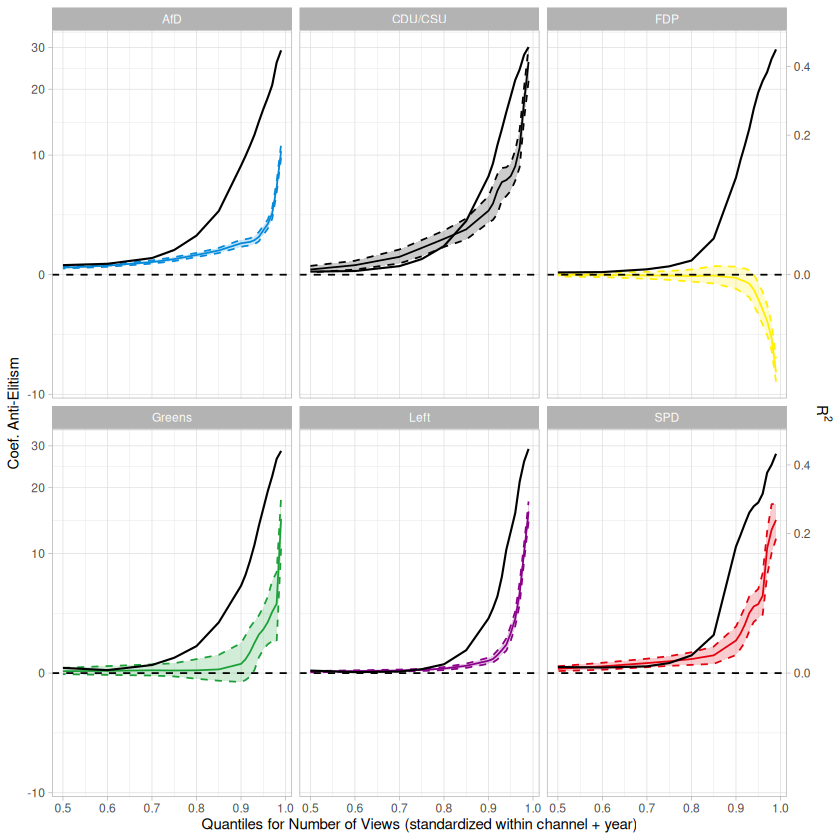

In [13]:
df_elite <- df |>
    filter(model_type == "views_elite", term == "elite")

df_r2 <- df |>
    filter(model_type == "views_elite", term == "R2") %>%
    transmute(party, quantile, R2 = est)

plot_df <- df_elite |>
    left_join(df_r2, by = c("party", "quantile"))

est_max <- max(plot_df$upper_ci, 0, na.rm = TRUE)
r2_max <- max(plot_df$R2, na.rm = TRUE)
a <- est_max / r2_max # zero-anchored linear mapping

to_primary <- function(r2) a * r2 # R2 -> primary y (0 -> 0)
to_secondary <- function(y) y / a # primary y -> R2    (0 -> 0)

plot <- ggplot(plot_df, aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_line(aes(y = to_primary(R2)), color = "black", linewidth = 0.6) +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantiles for Number of Views (standardized within channel + year)",
        y = "Coef. Anti-Elitism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    scale_y_continuous(
        trans = scales::pseudo_log_trans(sigma = 3.7),
        breaks = scales::pretty_breaks(),
        sec.axis = sec_axis(~ to_secondary(.), name = expression(R^2))
    ) +
    theme_light(base_size = 9) +
    theme(legend.position = "none")

plot


In [14]:
path <- here("reports", "figures", "reg_views_elite.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 17,
    height = 10
)


[1] TRUE

# Views Pplcentr


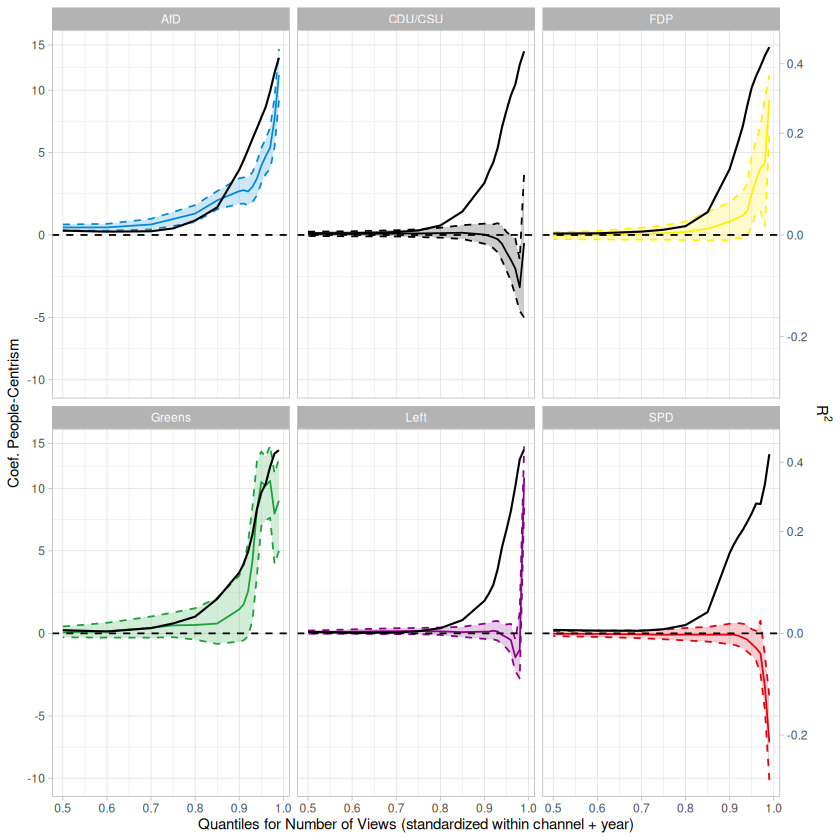

In [15]:
df_elite <- df |>
    filter(model_type == "views_pplcentr", term == "pplcentr")

df_r2 <- df |>
    filter(model_type == "views_pplcentr", term == "R2") %>%
    transmute(party, quantile, R2 = est)

plot_df <- df_elite %>% left_join(df_r2, by = c("party", "quantile"))

est_max <- max(plot_df$upper_ci, 0, na.rm = TRUE)
r2_max <- max(plot_df$R2, na.rm = TRUE)
a <- est_max / r2_max

to_primary <- function(r2) a * r2
to_secondary <- function(y) y / a

plot <- ggplot(plot_df, aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_line(aes(y = to_primary(R2)), color = "black", linewidth = 0.6) +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantiles for Number of Views (standardized within channel + year)",
        y = "Coef. People-Centrism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    scale_y_continuous(
        trans = scales::pseudo_log_trans(sigma = 3.7),
        breaks = scales::pretty_breaks(),
        sec.axis = sec_axis(~ to_secondary(.), name = expression(R^2))
    ) +
    theme_light(base_size = 9) +
    theme(legend.position = "none")

plot


In [16]:
path <- here("reports", "figures", "reg_views_pplcentr.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 17,
    height = 10
)


[1] TRUE

# Likes Elite


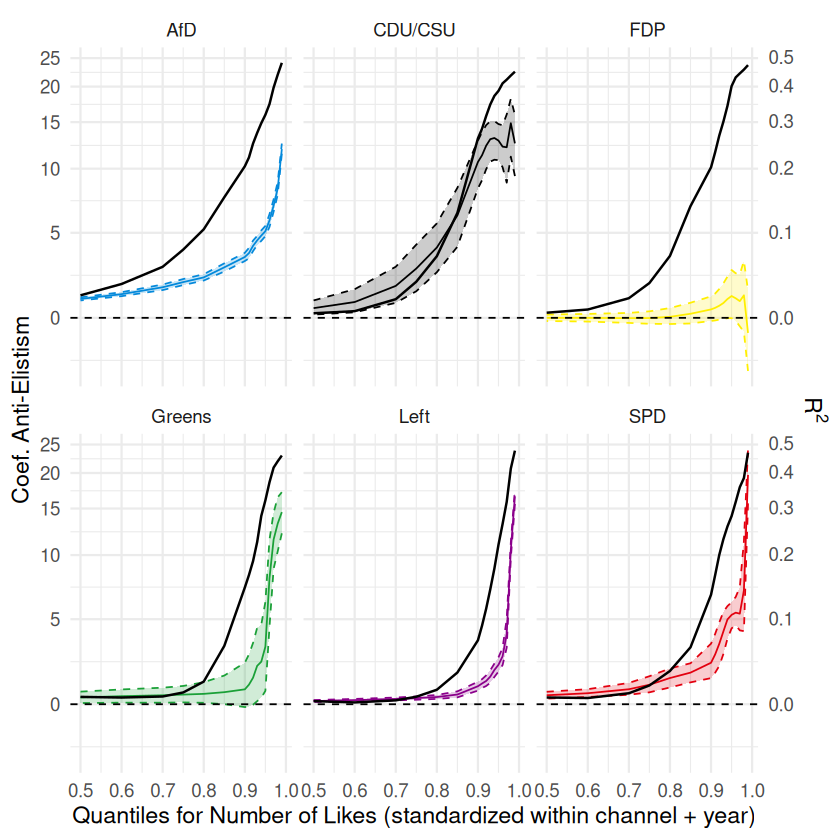

In [ ]:
df_elite <- df |>
    filter(model_type == "likes_elite", term == "elite")

df_r2 <- df |>
    filter(model_type == "likes_elite", term == "R2") %>%
    transmute(party, quantile, R2 = est)

plot_df <- df_elite |>
    left_join(df_r2, by = c("party", "quantile"))

est_max <- max(plot_df$upper_ci, 0, na.rm = TRUE)
r2_max <- max(plot_df$R2, na.rm = TRUE)
a <- est_max / r2_max

to_primary <- function(r2) a * r2
to_secondary <- function(y) y / a

plot <- ggplot(plot_df, aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_line(aes(y = to_primary(R2)), color = "black", linewidth = 0.6) +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantiles for Number of Likes (standardized within channel + year)",
        y = "Coef. Anti-Elistism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    scale_y_continuous(
        trans = scales::pseudo_log_trans(sigma = 3.7),
        breaks = scales::pretty_breaks(),
        sec.axis = sec_axis(~ to_secondary(.), name = expression(R^2))
    ) +
    theme_light(base_size = 9) +
    theme(legend.position = "none")

plot


In [16]:
path <- here("reports", "figures", "reg_likes_elite.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 17,
    height = 11
)


# Likes Pplcentr


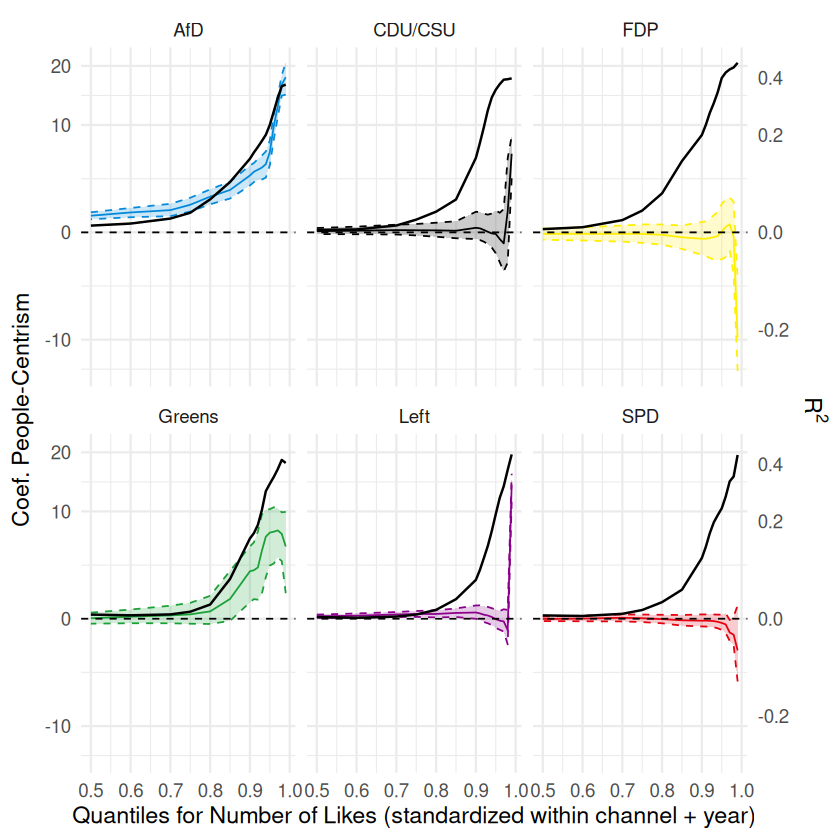

In [ ]:
df_elite <- df |>
    filter(model_type == "likes_pplcentr", term == "pplcentr")

df_r2 <- df |>
    filter(model_type == "likes_pplcentr", term == "R2") %>%
    transmute(party, quantile, R2 = est)

plot_df <- df_elite %>% left_join(df_r2, by = c("party", "quantile"))

est_max <- max(plot_df$upper_ci, 0, na.rm = TRUE)
r2_max <- max(plot_df$R2, na.rm = TRUE)
a <- est_max / r2_max

to_primary <- function(r2) a * r2
to_secondary <- function(y) y / a

plot <- ggplot(plot_df, aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_line(aes(y = to_primary(R2)), color = "black", linewidth = 0.6) +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantiles for Number of Likes (standardized within channel + year)",
        y = "Coef. People-Centrism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    scale_y_continuous(
        trans = scales::pseudo_log_trans(sigma = 3.7),
        breaks = scales::pretty_breaks(),
        sec.axis = sec_axis(~ to_secondary(.), name = expression(R^2))
    ) +
    theme_light(base_size = 9) +
    theme(legend.position = "none")

plot


In [18]:
path <- here("reports", "figures", "reg_likes_pplcentr.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 17,
    height = 11
)
